# Batch Reactor

A batch reactor is one of the fundamental reactor configurations in chemical reaction engineering.

In a batch reactor, reactants are charged into the reactor at the beginning of operation, and the reaction proceeds without continuous feed or product removal.

The composition of the reaction mixture changes with time as the reaction proceeds.

Batch reactors are commonly used in:

- Laboratory kinetic experiments
- Pharmaceutical production
- Specialty chemical manufacturing
- Small-scale biochemical processes

## 1. Physical concept of a batch reactor

A batch reactor is a closed reaction system where reactants are loaded at the beginning of the operation and products are removed only after the reaction is completed.

The main characteristics of an ideal batch reactor are:

- No continuous feed stream
- No continuous outlet stream
- Perfect mixing
- Uniform temperature and concentration throughout the reactor
- Reactor composition changes only with time

The general operation procedure is:

1. Charge reactants into the reactor

2. Start the reaction

3. Monitor the reaction progress with time

4. Stop the reactor and collect products

Unlike continuous reactors such as CSTR and PFR, the independent variable of a batch reactor is **time** rather than reactor volume.

Therefore, the performance of a batch reactor is usually described by:

- Concentration versus time
- Conversion versus time
- Reaction time required to reach a target conversion

## 2. Reaction system

To develop a reactor model, we first need to define the reaction system and its kinetics.

In this notebook, we consider a simple irreversible first-order reaction:

$$
A \rightarrow B
$$

The reaction rate is described by:

$$
-r_A = kC_A
$$

where:

- $ -r_A $ is the rate of disappearance of reactant A
- $ k $ is the reaction rate constant
- $ C_A $ is the concentration of reactant A

The first-order reaction model is selected because it provides a simple but powerful example to demonstrate the connection between:

$$
\text{Reaction kinetics}
\rightarrow
\text{Mole balance}
\rightarrow
\text{Reactor design equation}
$$

Although real chemical systems may involve complex reaction mechanisms, the modeling workflow remains the same.

## 3. Mole balance derivation

The mathematical model of a reactor is derived from the conservation principle.

The general mole balance equation is:

$$
\text{Input}
-
\text{Output}
+
\text{Generation}
=
\text{Accumulation}
$$

or:

$$
F_{A0}
-
F_A
+
r_AV
=
\frac{dN_A}{dt}
$$

where:

- $N_A$ is the number of moles of species A
- $F_{A0}$ is the inlet molar flow rate of A
- $F_A$ is the outlet molar flow rate of A
- $r_A$ is the rate of generation of A per unit volume
- $V$ is the reactor volume

---

### Batch reactor assumptions

For an ideal batch reactor:

#### 1. No inlet stream

$$
F_{A0}=0
$$

#### 2. No outlet stream

$$
F_A=0
$$

Therefore, the mole balance becomes:

$$
\frac{dN_A}{dt}=r_AV
$$

which is the design equation of ideal batch reactor.

---

### Constant volume sssumption

For a constant-volume batch reactor:

$$
N_A=C_AV
$$

Taking the derivative:

$$
\frac{dN_A}{dt}
=
V\frac{dC_A}{dt}
$$

Substituting into the mole balance:

$$
V\frac{dC_A}{dt}=r_AV
$$

The reactor volume cancels:

$$
\frac{dC_A}{dt}=r_A
$$

---

### Applying reaction kinetics

For the first-order irreversible reaction:

$$
A\rightarrow B
$$

the rate expression is:

$$
-r_A=kC_A
$$

Therefore:

$$
r_A=-kC_A
$$

The governing equation of the batch reactor becomes:

$$
\boxed{
\frac{dC_A}{dt}=-kC_A
}
$$

This differential equation describes how the concentration of reactant A changes with time inside the batch reactor.

## 4. Analytical solution of batch reactor model

The governing equation of the batch reactor is:

$$
\frac{dC_A}{dt}=-kC_A
$$

This equation describes the change of reactant concentration with time.

To obtain the analytical solution, we separate the variables:

$$
\frac{dC_A}{C_A}=-kdt
$$

Integrating both sides:

$$
\int_{C_{A0}}^{C_A}\frac{dC_A}{C_A}
=
\int_0^t -kdt
$$

The result is:

$$
\ln{\frac{C_A}{C_{A0}}}=-kt
$$

Rearranging:

$$
\boxed{
C_A=C_{A0}e^{-kt}
}
$$

This equation describes the concentration profile inside an ideal batch reactor.

---

### Conversion relationship


In reactor design, conversion is often used instead of concentration.


The conversion of reactant A is defined as:

$$
X_A=
\frac{C_{A0}-C_A}{C_{A0}}
$$

Substituting the analytical solution:

$$
X_A=
1-\frac{C_A}{C_{A0}}
$$

Therefore:

$$
\boxed{
X_A=1-e^{-kt}
}
$$

The conversion increases with reaction time and approaches 1 as the reaction proceeds.

---

### Engineering interpretation

The analytical solution shows the relationship between reaction kinetics and reactor performance:

- A larger rate constant $k$ leads to faster reactant consumption.
- A longer reaction time increases conversion.
- The required batch reaction time depends directly on the reaction kinetics.

The analytical solution provides a reference for validating numerical simulations in Python.

## 5. Python simulation: analytical solution

In this section, we implement the analytical solution of the batch reactor model using Python.

The governing equation is:

$$
C_A=C_{A0}e^{-kt}
$$

where:

- $C_{A0}$ is the initial concentration of reactant A
- $C_A$ is the concentration at time $t$
- $k$ is the reaction rate constant

The simulation will calculate:

- Concentration profile $C_A(t)$
- Conversion profile $X_A(t)$

and visualize how the reaction proceeds with time.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Define model parameters

CA0 = 1.0     # Initial concentration of A (mol/L)
k = 0.5       # Reaction rate constant (1/min)
t = np.linspace(0, 10, 200)

In [16]:
# Analytical solution

CA = CA0 * np.exp(-k*t)

CA[:5]

array([1.        , 0.97518739, 0.95099045, 0.9273939 , 0.90438284])

In [17]:
# Calculate conversion

X = (CA0 - CA) / CA0

X[:5]

array([0.        , 0.02481261, 0.04900955, 0.0726061 , 0.09561716])

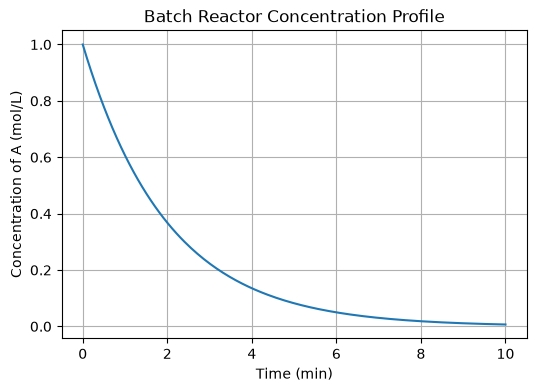

In [18]:
plt.figure(figsize=(6,4))

plt.plot(t, CA)

plt.xlabel("Time (min)")
plt.ylabel("Concentration of A (mol/L)")

plt.title("Batch Reactor Concentration Profile")

plt.grid()

plt.show()

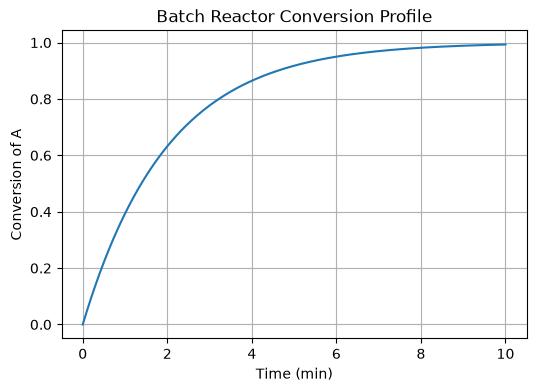

In [19]:
plt.figure(figsize=(6,4))

plt.plot(t, X)

plt.xlabel("Time (min)")
plt.ylabel("Conversion of A")

plt.title("Batch Reactor Conversion Profile")

plt.grid()

plt.show()

## 6. Numerical solution using ODE solver

The analytical solution provides an exact solution for simple reaction systems.

However, many engineering models cannot be solved analytically because they may contain:

- complex reaction mechanisms
- nonlinear kinetics
- multiple reactions
- heat and mass transfer effects

In these cases, numerical methods are required.

The batch reactor model can be written as an ordinary differential equation (ODE):

$$
\frac{dC_A}{dt}=-kC_A
$$

Instead of directly using the analytical solution, we can solve this differential equation numerically using Python.

In [20]:
from scipy.integrate import solve_ivp

### Define the reactor model

The reactor model is represented as a differential equation.

The function below describes the rate of concentration change:

$$
\frac{dC_A}{dt}=f(C_A,t)
$$


For a first-order reaction:

$$
f(C_A,t)=-kC_A
$$

In [21]:
def batch_reactor_model(t, CA, k):

    dCAdt = -k * CA

    return dCAdt

In [22]:
solution = solve_ivp(
    batch_reactor_model,
    [0, 10],
    [CA0],
    args=(k,),
    t_eval=t
)

In [23]:
CA_numeric = solution.y[0]

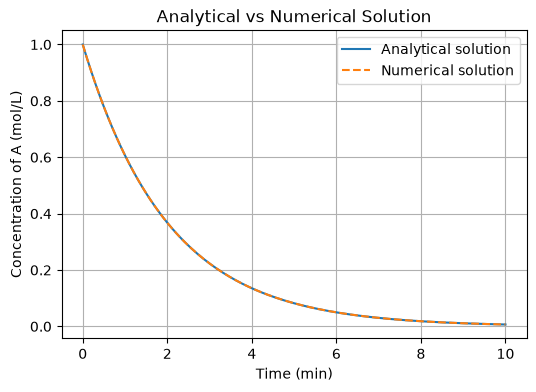

In [24]:
plt.figure(figsize=(6,4))

plt.plot(t, CA, label="Analytical solution")

plt.plot(
    solution.t,
    CA_numeric,
    "--",
    label="Numerical solution"
)

plt.xlabel("Time (min)")
plt.ylabel("Concentration of A (mol/L)")

plt.title("Analytical vs Numerical Solution")

plt.legend()

plt.grid()

plt.show()

## 7. Parameter analysis

The reactor performance depends strongly on reaction kinetics and operating conditions.

In this section, we investigate how the reaction rate constant affects batch reactor behavior.

The rate constant $k$ represents the speed of the chemical reaction:

$$
-r_A=kC_A
$$

A larger value of $k$ indicates a faster reaction rate.

We will compare different values of $k$ and analyze their influence on:

- Reactant concentration profile
- Conversion profile
- Required reaction time

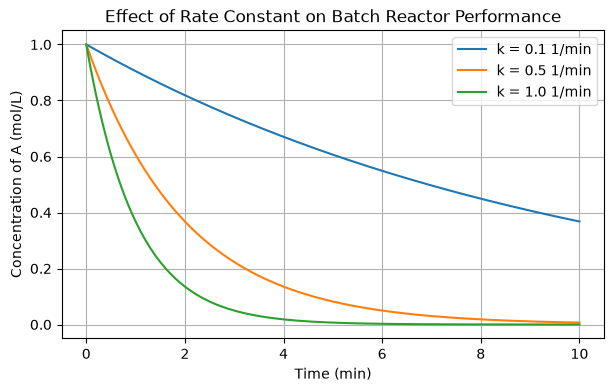

In [25]:
# Analyze the effect of reaction rate constant

k_values = [0.1, 0.5, 1.0]

plt.figure(figsize=(7,4))

for k_value in k_values:

    CA_profile = CA0 * np.exp(-k_value * t)

    plt.plot(
        t,
        CA_profile,
        label=f"k = {k_value} 1/min"
    )


plt.xlabel("Time (min)")
plt.ylabel("Concentration of A (mol/L)")

plt.title("Effect of Rate Constant on Batch Reactor Performance")

plt.legend()

plt.grid()

plt.show()

### Interpretation

The parameter analysis demonstrates the relationship between reaction kinetics and reactor performance.

From the simulation:

- Increasing the reaction rate constant accelerates reactant consumption.
- Faster reactions require shorter batch operation times.
- Reactor performance is directly controlled by reaction kinetics.

In practical applications, the rate constant can be affected by:

- Temperature
- Catalyst activity
- Reaction mechanism
- Operating conditions

Therefore, reactor design requires both:

$$
\text{Reaction kinetics}
+
\text{Reactor model}
$$

to predict process performance.

## 8. Engineering design interpretation

The purpose of reactor modeling is not only to predict concentration changes, but also to support engineering decisions.

For a batch reactor, the key design question is:

**How long should the reactor operate to achieve a desired conversion?**

From the analytical solution:

$$
X_A=1-e^{-kt}
$$

the required reaction time can be calculated as:

$$
t=
-\frac{1}{k}\ln(1-X_A)
$$

This equation connects:

$$
\text{Reaction kinetics}
\rightarrow
\text{Conversion target}
\rightarrow
\text{Operating time}
$$

In industrial applications, this relationship is used to determine:

- Batch cycle time
- Reactor productivity
- Production scheduling
- Process feasibility

In [26]:
# Calculate required batch time for a target conversion

X_target = 0.9

t_required = -np.log(1 - X_target) / k

print(
    f"Required reaction time for {X_target*100:.0f}% conversion: {t_required:.2f} min"
)

Required reaction time for 90% conversion: 4.61 min


## 9. Summary

In this notebook, we developed a complete computational model for an ideal batch reactor.

The workflow followed:

1. Defined the physical reactor system

2. Derived the mathematical model from a mole balance

3. Obtained the analytical solution

4. Implemented the model using Python

5. Verified the solution using numerical ODE integration

6. Analyzed the influence of kinetic parameters

7. Applied the model for reactor design

The key concept is:

$$
\boxed{
\text{Physical system}
\rightarrow
\text{Mathematical model}
\rightarrow
\text{Computational simulation}
\rightarrow
\text{Engineering design}
}
$$

This workflow will be applied to other reactor models, including:

- Continuous stirred tank reactors (CSTR)
- Plug flow reactors (PFR)
- Packed bed reactors (PBR)